<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/04_Hernandez_Alvaro_ImplementacionRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implementación de una RNN**

* Asignatura: Redes Neuronales Profundas
* Profesor: Dr. José David Díaz Román
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 7 de marzo de 2026




# **Indicaciones**

Basados en el ejemplo de implementación de una red neuronal recurrente compartido en el archivo Ejemplo RNN imdb, realice los siguientes experimentos:

* Replique los resultados obtenidos.
* Modifique la red neuronal recurrente simple por una capa LSTM dejando los mismos parámetros. Solo cambie la línea "layers.SimpleRNN(64)" por "layers.LSTM(64)" .
* A continuación, cambie la red LSTM por una GRU. Solo cambie la línea "layers.LSTM(64)" por  "layers.GRU(64)" .

Registre el desempeño de las redes con el conjunto de prueba y presente las curvas de entrenamiento: Accuracy vs. epochs y Loss vs. epochs, de los conjuntos de entrenamiento y validación.

Registre el tiempo de entrenamiento por época que tomaron en promedio cada una de las redes.


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
VOCAB_SIZE   = 10000     # top palabras
MAX_LEN      = 200       # longitud fija de secuencia

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

# Padding / truncado para longitud fija
x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding="pre", truncating="pre")
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding="pre", truncating="pre")

print(f"Train: {x_train.shape},  Test: {x_test.shape}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (25000, 200),  Test: (25000, 200)


In [3]:
rnn_model = keras.Sequential([
        keras.layers.Input(shape=(MAX_LEN,), dtype='int32'),
        keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128),
        layers.SimpleRNN(64),                     # RNN básica
        layers.Dense(1, activation="sigmoid")     # binaria
])
rnn_model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
hist_rnn = rnn_model.fit(
    x_train, y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=2
)
rnn_test_loss, rnn_test_acc = rnn_model.evaluate(x_test, y_test, verbose=0)
print(f"[SimpleRNN] Test acc: {rnn_test_acc:.4f} | loss: {rnn_test_loss:.4f}")

Epoch 1/10
333/333 - 31s - 92ms/step - accuracy: 0.6841 - loss: 0.5667 - val_accuracy: 0.7453 - val_loss: 0.5181
Epoch 2/10
333/333 - 39s - 117ms/step - accuracy: 0.8417 - loss: 0.3648 - val_accuracy: 0.8299 - val_loss: 0.4329
Epoch 3/10
333/333 - 28s - 85ms/step - accuracy: 0.8791 - loss: 0.2833 - val_accuracy: 0.8189 - val_loss: 0.4718
Epoch 4/10
333/333 - 27s - 82ms/step - accuracy: 0.9383 - loss: 0.1584 - val_accuracy: 0.7213 - val_loss: 0.7416
Epoch 5/10
333/333 - 41s - 123ms/step - accuracy: 0.9844 - loss: 0.0516 - val_accuracy: 0.7624 - val_loss: 0.7762
Epoch 6/10
333/333 - 27s - 81ms/step - accuracy: 0.9955 - loss: 0.0186 - val_accuracy: 0.7405 - val_loss: 0.9647
Epoch 7/10
333/333 - 41s - 122ms/step - accuracy: 0.9967 - loss: 0.0130 - val_accuracy: 0.7797 - val_loss: 0.9206
[SimpleRNN] Test acc: 0.8276 | loss: 0.4308


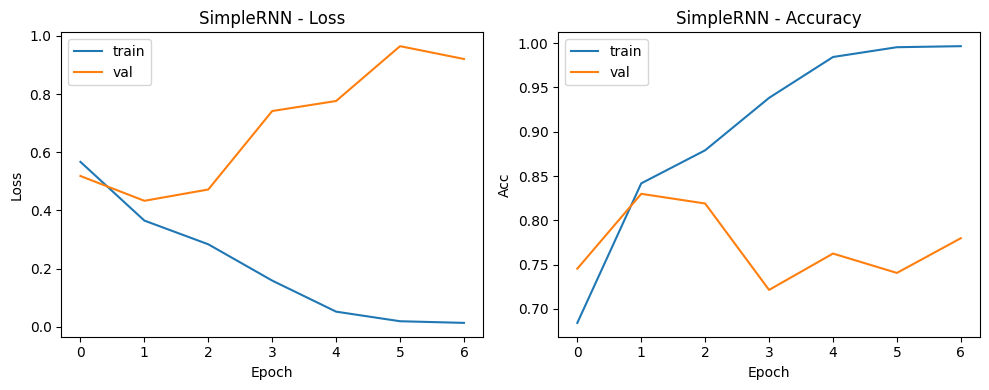

SimpleRNN -> Test acc: 0.8276 | Test loss: 0.4308


In [5]:
def plot_history(hist, title):
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    ax[0].plot(hist.history["loss"], label="train")
    ax[0].plot(hist.history["val_loss"], label="val")
    ax[0].set_title(f"{title} - Loss"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend()
    ax[1].plot(hist.history["accuracy"], label="train")
    ax[1].plot(hist.history["val_accuracy"], label="val")
    ax[1].set_title(f"{title} - Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Acc"); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_history(hist_rnn, "SimpleRNN")

print(f"SimpleRNN -> Test acc: {rnn_test_acc:.4f} | Test loss: {rnn_test_loss:.4f}")

In [ ]:
rnn_model = keras.Sequential([
        keras.layers.Input(shape=(MAX_LEN,), dtype='int32'),
        keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128),
        layers.SimpleRNN(64),                     # RNN básica
        layers.Dense(1, activation="sigmoid")     # binaria
])
rnn_model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

rnn_model.summary()

### **Definición del modelo LSTM**

In [6]:
# Definición del modelo LSTM
lstm_model = keras.Sequential([
    keras.layers.Input(shape=(MAX_LEN,), dtype='int32'),
    keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128),
    layers.LSTM(64),                                      # Capa LSTM
    layers.Dense(1, activation="sigmoid")                 # Binaria
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks_lstm = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
]

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
333/333 - 83s - 249ms/step - accuracy: 0.7995 - loss: 0.4287 - val_accuracy: 0.8533 - val_loss: 0.3527
Epoch 2/10
333/333 - 79s - 236ms/step - accuracy: 0.9016 - loss: 0.2522 - val_accuracy: 0.8672 - val_loss: 0.3329
Epoch 3/10
333/333 - 86s - 258ms/step - accuracy: 0.9321 - loss: 0.1802 - val_accuracy: 0.8595 - val_loss: 0.3504
Epoch 4/10
333/333 - 77s - 231ms/step - accuracy: 0.9463 - loss: 0.1458 - val_accuracy: 0.8624 - val_loss: 0.4548
Epoch 5/10
333/333 - 78s - 233ms/step - accuracy: 0.9625 - loss: 0.1059 - val_accuracy: 0.8576 - val_loss: 0.5087
Epoch 6/10
333/333 - 75s - 227ms/step - accuracy: 0.9712 - loss: 0.0844 - val_accuracy: 0.8440 - val_loss: 0.5342
Epoch 7/10
333/333 - 76s - 229ms/step - accuracy: 0.9824 - loss: 0.0538 - val_accuracy: 0.8571 - val_loss: 0.5710


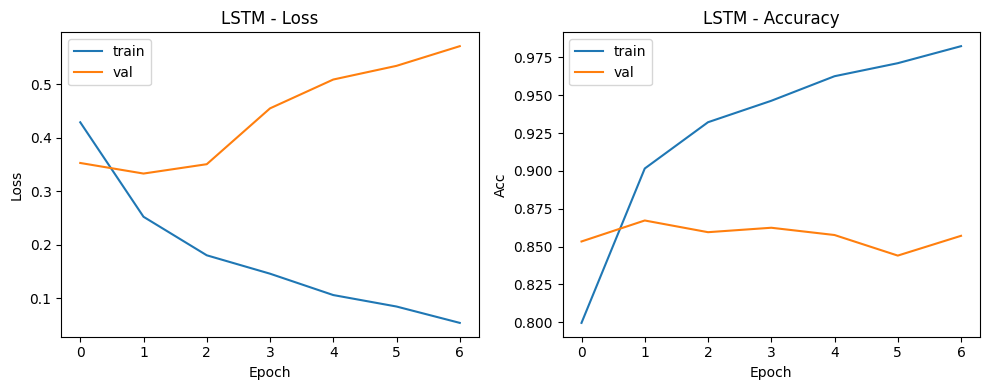

[LSTM] Test acc: 0.8624 | loss: 0.3453


In [7]:
hist_lstm = lstm_model.fit(
    x_train, y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=64,
    callbacks=callbacks_lstm,
    verbose=2
)

lstm_test_loss, lstm_test_acc = lstm_model.evaluate(x_test, y_test, verbose=0)
plot_history(hist_lstm, "LSTM")
print(f"[LSTM] Test acc: {lstm_test_acc:.4f} | loss: {lstm_test_loss:.4f}")

### **Definición del modelo GRU**

In [8]:
gru_model = keras.Sequential([
    keras.layers.Input(shape=(MAX_LEN,), dtype='int32'),
    keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128),
    layers.GRU(64),                                       # Capa GRU
    layers.Dense(1, activation="sigmoid")                 # Binaria
])

gru_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks_gru = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
]

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,313 (5.03 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
333/333 - 87s - 260ms/step - accuracy: 0.7502 - loss: 0.5662 - val_accuracy: 0.8381 - val_loss: 0.3763
Epoch 2/10
333/333 - 85s - 256ms/step - accuracy: 0.8852 - loss: 0.2910 - val_accuracy: 0.8571 - val_loss: 0.3532
Epoch 3/10
333/333 - 142s - 428ms/step - accuracy: 0.9247 - loss: 0.2059 - val_accuracy: 0.8552 - val_loss: 0.3479
Epoch 4/10
333/333 - 84s - 253ms/step - accuracy: 0.9448 - loss: 0.1576 - val_accuracy: 0.8611 - val_loss: 0.3988
Epoch 5/10
333/333 - 142s - 425ms/step - accuracy: 0.9600 - loss: 0.1161 - val_accuracy: 0.8539 - val_loss: 0.4332
Epoch 6/10
333/333 - 84s - 254ms/step - accuracy: 0.9724 - loss: 0.0808 - val_accuracy: 0.8597 - val_loss: 0.5731
Epoch 7/10
333/333 - 141s - 425ms/step - accuracy: 0.9782 - loss: 0.0667 - val_accuracy: 0.8544 - val_loss: 0.5216
Epoch 8/10
333/333 - 82s - 248ms/step - accuracy: 0.9844 - loss: 0.0497 - val_accuracy: 0.8515 - val_loss: 0.5978


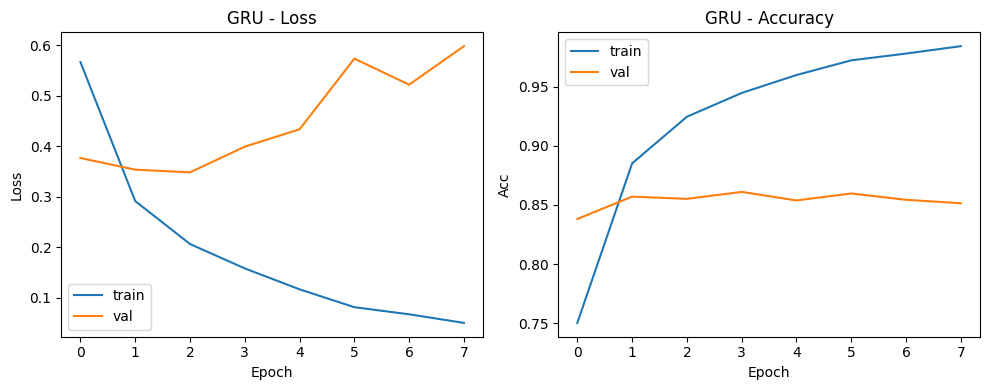

GRU -> Test acc: 0.8546 | Test loss: 0.3552


In [9]:
hist_gru = gru_model.fit(
    x_train, y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=64,
    callbacks=callbacks_gru,
    verbose=2
)

gru_test_loss, gru_test_acc = gru_model.evaluate(x_test, y_test, verbose=0)
plot_history(hist_gru, "GRU")
print(f"GRU -> Test acc: {gru_test_acc:.4f} | Test loss: {gru_test_loss:.4f}")

### Comparación

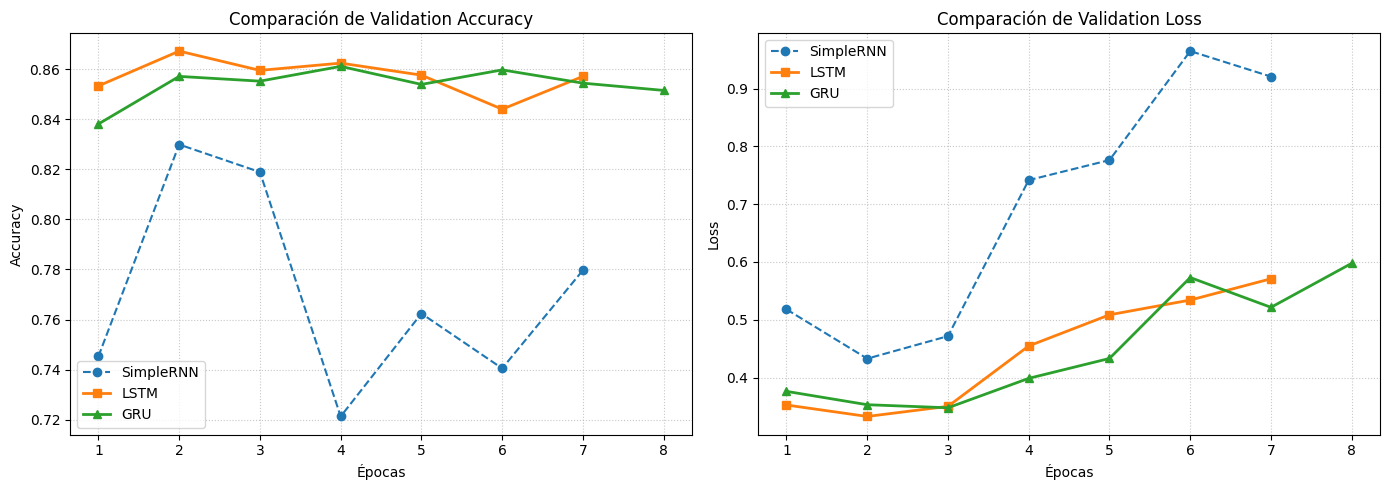

In [10]:
import matplotlib.pyplot as plt


# SimpleRNN: 7 épocas
epochs_rnn = range(1, 8)
val_acc_rnn = [0.7453, 0.8299, 0.8189, 0.7213, 0.7624, 0.7405, 0.7797]
val_loss_rnn = [0.5181, 0.4329, 0.4718, 0.7416, 0.7762, 0.9647, 0.9206]

# LSTM: 7 épocas
epochs_lstm = range(1, 8)
val_acc_lstm = [0.8533, 0.8672, 0.8595, 0.8624, 0.8576, 0.8440, 0.8571]
val_loss_lstm = [0.3527, 0.3329, 0.3504, 0.4548, 0.5087, 0.5342, 0.5710]

# GRU: 8 épocas
epochs_gru = range(1, 9)
val_acc_gru = [0.8381, 0.8571, 0.8552, 0.8611, 0.8539, 0.8597, 0.8544, 0.8515]
val_loss_gru = [0.3763, 0.3532, 0.3479, 0.3988, 0.4332, 0.5731, 0.5216, 0.5978]


fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfica de Accuracy
ax[0].plot(epochs_rnn, val_acc_rnn, label="SimpleRNN", marker='o', linestyle='--')
ax[0].plot(epochs_lstm, val_acc_lstm, label="LSTM", marker='s', linewidth=2)
ax[0].plot(epochs_gru, val_acc_gru, label="GRU", marker='^', linewidth=2)
ax[0].set_title("Comparación de Validation Accuracy")
ax[0].set_xlabel("Épocas")
ax[0].set_ylabel("Accuracy")
ax[0].grid(True, linestyle=':', alpha=0.7)
ax[0].legend()

# 2. Gráfica de Loss
ax[1].plot(epochs_rnn, val_loss_rnn, label="SimpleRNN", marker='o', linestyle='--')
ax[1].plot(epochs_lstm, val_loss_lstm, label="LSTM", marker='s', linewidth=2)
ax[1].plot(epochs_gru, val_loss_gru, label="GRU", marker='^', linewidth=2)
ax[1].set_title("Comparación de Validation Loss")
ax[1].set_xlabel("Épocas")
ax[1].set_ylabel("Loss")
ax[1].grid(True, linestyle=':', alpha=0.7)
ax[1].legend()

plt.tight_layout()
plt.show()

$$
\begin{array}{|l|l|c|}
\hline
\textbf{Modelo de Red} & \textbf{Tiempos por época registrados (segundos)} & \textbf{Promedio (s)} \\
\hline
\text{SimpleRNN} & \text{31, 39, 28, 27, 41, 27, 41} & 33.43 \\
\hline
\text{LSTM} & \text{83, 79, 86, 77, 78, 75, 76} & 79.14 \\
\hline
\text{GRU} & \text{87, 85, 142, 84, 142, 84, 141, 82} & 105.88 \\
\hline
\end{array}
$$

## **Conclusiones:**
El modelo SimpleTNN toma menos tiempo, pero tiene un Accuracy más bajo, por lo que los modelos LSTM y GRU son mejores, con un costo computacional más alto